# Credit Risk Prediction — German Credit Data

**Author:** Benjamín Pavlov

## Project goal

This project explores the German Credit dataset (UCI Statlog) to answer a practical business question:

> *Can we predict whether a loan applicant is a good or bad credit risk based on their profile, and which factors drive that risk the most?*

The second part matters as much as the first. A bank doesn't just want a black-box prediction, it wants to understand *why* a client is risky, so the model's findings can inform real lending decisions.

The dataset contains 1,000 loan applicants, each described by 20 attributes (financial status, credit history, employment, demographics, etc.), with a target variable indicating good vs. bad credit risk.

It also ships with an official **cost matrix**: misclassifying a bad risk as good costs 5 units, the reverse costs 1. "The best model" is therefore defined up front: the one that **minimises expected misclassification cost** at its optimal decision threshold, while staying interpretable enough to explain. That definition will drive the model selection later in the project.

**Workflow:** data loading → cleaning & decoding → SQLite storage & SQL exploration → EDA → preprocessing → model comparison & tuning (two imbalance strategies) → cost-based model selection & threshold tuning → final test evaluation → interpretation → conclusions.

## 1. Loading and preparing the data

The raw data comes as a space-separated file with no header and categorical values encoded as codes (e.g. `A11`, `A34`). The first steps are to load it, give the columns meaningful names, and decode those codes into readable labels.

In [109]:
import pandas as pd
import numpy as np

df = pd.read_csv("german.data", header=None, sep=" ")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


The raw file has no column names, so pandas assigns numbers 0–20. The next step assigns names based on the dataset's data dictionary.

In [110]:
df.columns = [
    'checking_account',      # status of existing checking account
    'duration_months',       # loan duration in months
    'credit_history',        # credit history
    'purpose',               # purpose of the loan
    'credit_amount',         # loan amount
    'savings_account',       # savings
    'employment_since',      # length of current employment
    'installment_rate',      # installment as % of disposable income
    'personal_status_sex',   # personal status and sex
    'other_debtors',         # other debtors / guarantors
    'residence_since',       # years at current residence
    'property',              # property owned
    'age',                   # age in years
    'other_installment',     # other installment plans
    'housing',               # housing (own / rent / free)
    'existing_credits',      # number of existing credits at this bank
    'job',                   # job type
    'people_liable',         # number of dependents
    'telephone',             # telephone yes/no
    'foreign_worker',        # foreign worker yes/no
    'risk'                   # TARGET: 1 = good, 2 = bad risk
]
df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment,housing,existing_credits,job,people_liable,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


### Data dictionary

For reference, here is what each feature represents and how the codes map to real values:

**Financial / account**
- `checking_account` — status of checking account: A11 (< 0 DM), A12 (0–200 DM), A13 (≥ 200 DM), A14 (no account)
- `savings_account` — savings: A61 (< 100 DM) up to A65 (unknown/none)
- `credit_amount` — loan amount in DM *(numerical)*
- `duration_months` — loan length in months *(numerical)*
- `installment_rate` — installment as % of disposable income, scale 1–4

**History & purpose**
- `credit_history` — A30 (no credits/all paid) to A34 (critical account)
- `purpose` — A40 (new car), A41 (used car), A42 (furniture), A43 (radio/TV), A46 (education), etc.
- `existing_credits` — number of credits at this bank (1–4)
- `other_installment` — other installment plans: A141 (bank), A142 (stores), A143 (none)

**Personal / social**
- `personal_status_sex` — combined marital status and sex (A91–A95)
- `age` — age in years *(numerical)*
- `job` — A171 (unskilled) to A174 (management/self-employed)
- `employment_since` — A71 (unemployed) to A75 (≥ 7 years)
- `housing` — A151 (rent), A152 (own), A153 (free)
- `property` — type of property owned
- `residence_since` — years at current address (1–4)

**Other**
- `other_debtors` — A101 (none), A102 (co-applicant), A103 (guarantor)
- `people_liable` — number of dependents (1–2)
- `telephone` — A191 (none), A192 (yes)
- `foreign_worker` — A201 (yes), A202 (no)
- `risk` — **target**: 1 = good, 2 = bad risk

### Decoding categorical values

The coded values (`A11`, `A34`, ...) aren't readable, so I map them to descriptive labels using a dictionary of mappings. The same step also recodes the target `risk` from 1/2 to 0/1 (0 = good, 1 = bad), which is the standard convention for binary classification.

In [111]:
mappings = {
    'checking_account': {
        'A11': '< 0 DM', 'A12': '0-200 DM',
        'A13': '>= 200 DM', 'A14': 'no account'
    },
    'credit_history': {
        'A30': 'no credits/all paid', 'A31': 'all paid this bank',
        'A32': 'paid duly till now', 'A33': 'past delays',
        'A34': 'critical account'
    },
    'purpose': {
        'A40': 'car (new)', 'A41': 'car (used)', 'A42': 'furniture/equipment',
        'A43': 'radio/TV', 'A44': 'domestic appliances', 'A45': 'repairs',
        'A46': 'education', 'A47': 'vacation', 'A48': 'retraining',
        'A49': 'business', 'A410': 'others'
    },
    'savings_account': {
        'A61': '< 100 DM', 'A62': '100-500 DM', 'A63': '500-1000 DM',
        'A64': '>= 1000 DM', 'A65': 'unknown/none'
    },
    'employment_since': {
        'A71': 'unemployed', 'A72': '< 1 year', 'A73': '1-4 years',
        'A74': '4-7 years', 'A75': '>= 7 years'
    },
    'personal_status_sex': {
        'A91': 'male divorced', 'A92': 'female div/married',
        'A93': 'male single', 'A94': 'male married', 'A95': 'female single'
    },
    'other_debtors': {
        'A101': 'none', 'A102': 'co-applicant', 'A103': 'guarantor'
    },
    'property': {
        'A121': 'real estate', 'A122': 'savings/life insurance',
        'A123': 'car/other', 'A124': 'unknown/none'
    },
    'other_installment': {
        'A141': 'bank', 'A142': 'stores', 'A143': 'none'
    },
    'housing': {
        'A151': 'rent', 'A152': 'own', 'A153': 'for free'
    },
    'job': {
        'A171': 'unskilled non-resident', 'A172': 'unskilled resident',
        'A173': 'skilled employee', 'A174': 'management/self-employed'
    },
    'telephone': {
        'A191': 'none', 'A192': 'yes'
    },
    'foreign_worker': {
        'A201': 'yes', 'A202': 'no'
    },
    'risk': {
        1: 0, 2: 1   # 0 = good risk, 1 = bad risk
    }
}

for col, mapping in mappings.items():
    df[col] = df[col].map(mapping)

df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment,housing,existing_credits,job,people_liable,telephone,foreign_worker,risk
0,< 0 DM,6,critical account,radio/TV,1169,unknown/none,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,0
1,0-200 DM,48,paid duly till now,radio/TV,5951,< 100 DM,1-4 years,2,female div/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,1
2,no account,12,critical account,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,paid duly till now,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings/life insurance,45,none,for free,1,skilled employee,2,none,yes,0
4,< 0 DM,24,past delays,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,1


### Initial data check

Before any analysis, I check the structure: data types, missing values, and the balance of the target variable.

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   checking_account     1000 non-null   str  
 1   duration_months      1000 non-null   int64
 2   credit_history       1000 non-null   str  
 3   purpose              1000 non-null   str  
 4   credit_amount        1000 non-null   int64
 5   savings_account      1000 non-null   str  
 6   employment_since     1000 non-null   str  
 7   installment_rate     1000 non-null   int64
 8   personal_status_sex  1000 non-null   str  
 9   other_debtors        1000 non-null   str  
 10  residence_since      1000 non-null   int64
 11  property             1000 non-null   str  
 12  age                  1000 non-null   int64
 13  other_installment    1000 non-null   str  
 14  housing              1000 non-null   str  
 15  existing_credits     1000 non-null   int64
 16  job                  1000 non-null  

All columns have 1,000 non-null entries — **no missing values**, which is unusual for real data but saves us imputation work. The types split into 8 numerical and 13 categorical features.

In [113]:
df['risk'].value_counts()

risk
0    700
1    300
Name: count, dtype: int64

The target is **imbalanced**: 700 good risks (0) vs. 300 bad risks (1), a 70/30 split. This matters for modelling becouse a naive model predicting "good" for everyone would score 70% accuracy while catching zero bad risks. We'll account for this when choosing evaluation metrics.

## 2. Storing data in SQLite and exploring with SQL

In a real setting, data usually lives in a database rather than a CSV. To reflect that workflow, I store the prepared data in a local SQLite database and run a few SQL queries to get a first feel for how risk relates to the features.

In [114]:
import sqlite3

conn = sqlite3.connect('german_credit.db')

df.to_sql('loans', conn, if_exists='replace', index=False)
print("Data saved to database.")

Data saved to database.


**Quick check** — pull the first five rows back via SQL to confirm the connection works:

In [115]:
query = "SELECT * FROM loans LIMIT 5"
pd.read_sql(query, conn)

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment,housing,existing_credits,job,people_liable,telephone,foreign_worker,risk
0,< 0 DM,6,critical account,radio/TV,1169,unknown/none,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee,1,yes,yes,0
1,0-200 DM,48,paid duly till now,radio/TV,5951,< 100 DM,1-4 years,2,female div/married,none,...,real estate,22,none,own,1,skilled employee,1,none,yes,1
2,no account,12,critical account,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,paid duly till now,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings/life insurance,45,none,for free,1,skilled employee,2,none,yes,0
4,< 0 DM,24,past delays,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown/none,53,none,for free,2,skilled employee,2,none,yes,1


### How do good and bad risks differ on key numbers?

A first business question: do risky clients differ from safe ones in for example loan amount, age, or duration? I group by `risk` and compare averages.

In [116]:
query = """
SELECT
    risk,
    COUNT(*) AS num_clients,
    AVG(credit_amount) AS avg_loan,
    AVG(age) AS avg_age,
    AVG(duration_months) AS avg_duration
FROM loans
GROUP BY risk
"""
pd.read_sql(query, conn)

,risk,num_clients,avg_loan,avg_age,avg_duration
0,0,700,2985.457143,36.224286,19.207143
1,1,300,3938.126667,33.963333,24.860000


Bad risks (1) take **larger loans** (≈3,938 vs. 2,985 DM) over **longer durations** (≈25 vs. 19 months), but their average age is almost identical (≈34 vs. 36). 

### Risk by purpose of the loan

Since `risk` is coded 0/1, the average of `risk` within a group equals the *proportion* of bad risks in that group. I use this to rank loan purposes by riskiness.

In [117]:
query = """
SELECT purpose, COUNT(*) AS num_clients, AVG(risk) AS bad_risk_rate
FROM loans
GROUP BY purpose
ORDER BY bad_risk_rate DESC
"""
pd.read_sql(query, conn)

,purpose,num_clients,bad_risk_rate
0,education,50,0.440000
1,others,12,0.416667
2,car (new),234,0.380342
3,repairs,22,0.363636
4,business,97,0.350515
5,domestic appliances,12,0.333333
6,furniture/equipment,181,0.320442
7,radio/TV,280,0.221429
8,car (used),103,0.165049
9,retraining,9,0.111111


`education` shows the highest bad-risk rate, but it's a small group. More importantly, `car (new)` combines a *high* bad-risk rate with a *large* number of clients, making it arguably the more significant risk segment in practice. Reading risk together with volume, not in isolation, is the key here.

### Does risk vary across age groups?
Grouping clients according to their age group could reveal a pattern.

In [118]:
query = """
SELECT CASE WHEN age<30 THEN "young" WHEN age <40 THEN "adult" WHEN age < 60 THEN "middle_aged" ELSE "senior" END AS age_group, COUNT(*) AS num_clients, AVG(risk) AS risk_rate
FROM loans
GROUP BY age_group
ORDER BY risk_rate DESC
"""
pd.read_sql(query, conn)    

,age_group,num_clients,risk_rate
0,young,371,0.369272
1,middle_aged,248,0.262097
2,adult,330,0.257576
3,senior,51,0.254902


Younger clients (under 30) have the highest bad-risk rate at ~37%, declining steadily to ~22% for seniors. Lets filter for a specific risky-looking segment: **Young clients with large loans**: applicants under 30 who borrowed more than 5,000 DM:

In [119]:
query = """
SELECT age, credit_amount, duration_months, risk
FROM loans
WHERE age < 30 AND credit_amount > 5000
ORDER BY credit_amount DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,age,credit_amount,duration_months,risk
0,23,15672,48,1
1,21,15653,60,0
2,23,14555,6,1
3,25,14421,48,1
4,27,14027,60,1
5,29,11816,45,1
6,24,11590,48,1
7,23,11560,24,1
8,29,11328,24,1
9,26,10974,36,1


Of the largest loans in this young-borrower segment, almost all are bad risks (1). The combination of young age and a large loan looks strongly associated with risk, a pattern worth confirming visually in the EDA.

### Are larger-than-average loans riskier?

Splitting clients into those who borrowed above vs. below the average loan amount:

In [120]:
query = """
SELECT CASE WHEN credit_amount < (SELECT AVG(credit_amount) FROM loans) THEN "below_average" ELSE "above_average" END AS credit_group, COUNT(*) AS num_clients, AVG(risk) AS risk_rate
FROM loans
GROUP BY credit_group
""" 
pd.read_sql(query, conn)

,credit_group,num_clients,risk_rate
0,above_average,342,0.362573
1,below_average,658,0.267477


The above-average group has a bad-risk rate of ~36%, compared to ~27% for below-average — roughly a third higher. Loan size looks like a meaningful risk factor

### Relation to family status and dependent people
Breaking risk down by personal status and number of dependents (keeping only groups large enough to be reliable) isolates a clear signal:

In [121]:
query = """
SELECT personal_status_sex, people_liable, COUNT(*) AS num_clients, AVG(risk) AS risk_rate
FROM loans
GROUP BY personal_status_sex, people_liable
HAVING COUNT(*) > 10
ORDER BY risk_rate DESC
"""
pd.read_sql(query, conn)

,personal_status_sex,people_liable,num_clients,risk_rate
0,female div/married,2,14,0.428571
1,male divorced,1,47,0.425532
2,female div/married,1,296,0.347973
3,male single,2,136,0.286765
4,male married,1,90,0.266667
5,male single,1,412,0.259709


Divorced males have a notably higher bad-risk rate (~43%) than married or single males (~26%). The number of dependents, on the other hand, shows little effect. Filtering out the very small groups matters here, without it groups of just 2–3 clients produced misleading rates of 0% or 50%.

## 3. Exploratory data analysis (EDA)

Lets move on to EDA to explore the data visually and statistically to find patterns that will guide modelling. 

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

### Age distribution

First, what does the client base look like by age?

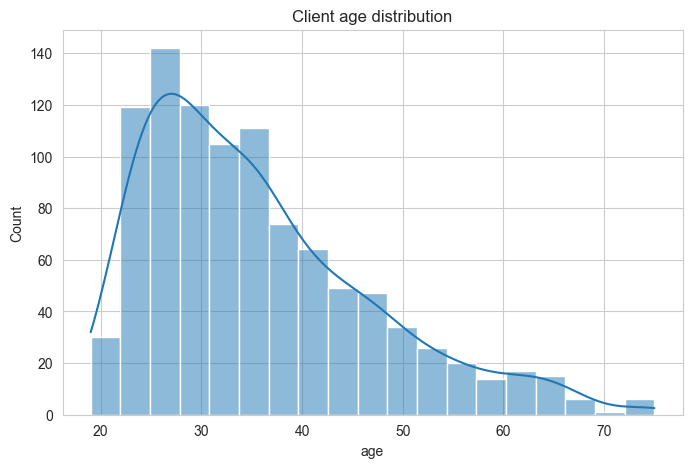

In [123]:
sns.histplot(data=df, x="age", kde=True)
plt.title("Client age distribution")
plt.show()

The distribution is **right-skewed**. Most clients are in their late 20s to 30s, with a long tail toward older ages. The typical client is around 30; the range runs from 19 to 75. This is worth noting since some methods assume roughly normal distributions.

### Does age relate to risk?

A more useful question than "how old are clients" is whether age *separates* good from bad risks. Because the classes are imbalanced, absolute counts are misleading, so I also look at the proportion of bad risk per age.

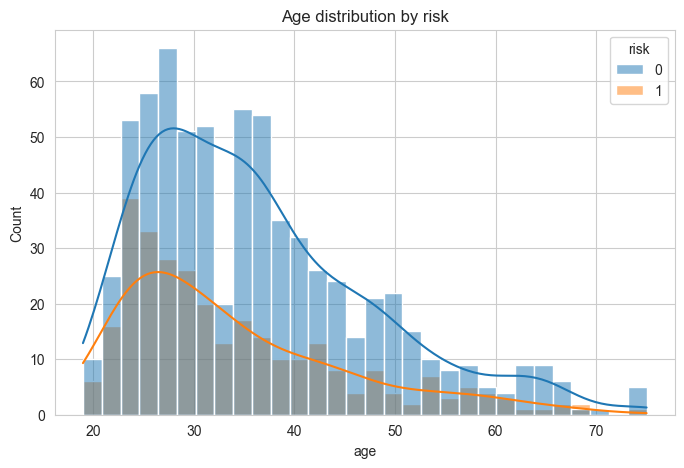

In [124]:
sns.histplot(data=df, x='age', hue='risk', kde=True, bins=30)
plt.title('Age distribution by risk')
plt.show()

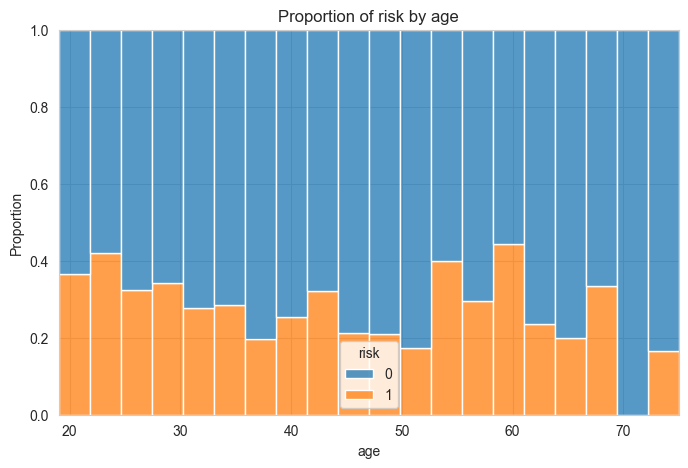

In [125]:
sns.histplot(data=df, x='age', hue='risk', multiple='fill', bins=20)
plt.title('Proportion of risk by age')
plt.ylabel('Proportion')
plt.show()

The proportion plot shows no strong trend. The bad-risk share hovers between roughly 0.2 and 0.45 across ages, with the youngest clients only slightly higher. The swings at 60+ are unreliable because those age bands contain very few clients. **Conclusion: age on its own is a weak predictor of risk**, consistent with the SQL finding that average ages were nearly identical across risk groups. 

### Risk by checking account status

Credit theory suggests financial-status features are strong predictors. Since `risk` is 0/1, a barplot of its mean per category gives the bad-risk rate directly.

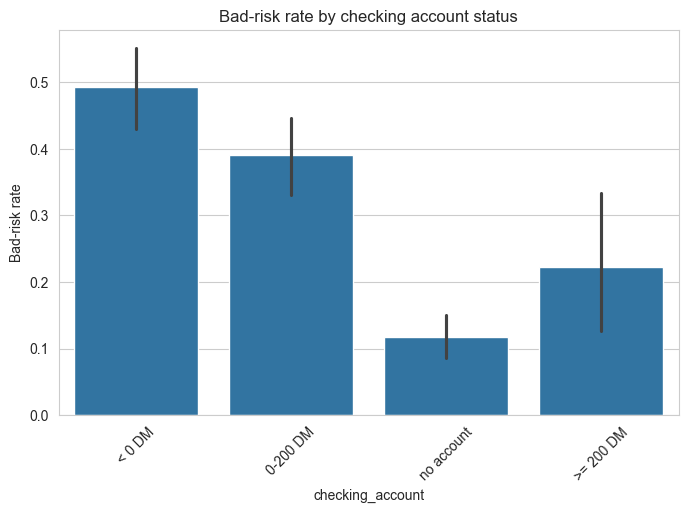

In [126]:
sns.barplot(data=df, x='checking_account', y='risk')
plt.title('Bad-risk rate by checking account status')
plt.ylabel('Bad-risk rate')
plt.xticks(rotation=45)
plt.show()

A clear pattern: clients with a negative balance (< 0 DM) have nearly **50% bad-risk rate**, falling as the balance rises. Interestingly, "no account" has the *lowest* risk — counterintuitive, but likely because these clients manage finances differently and aren't necessarily worse borrowers. The wide error bar on ">= 200 DM" reflects its small group size. This seems as a much stronger predictor than age.

### Risk by credit history

Credit history could be one of the strongest predictors. The bar chart shows the bad-risk rate per category, and the value counts below show how many clients fall into each.

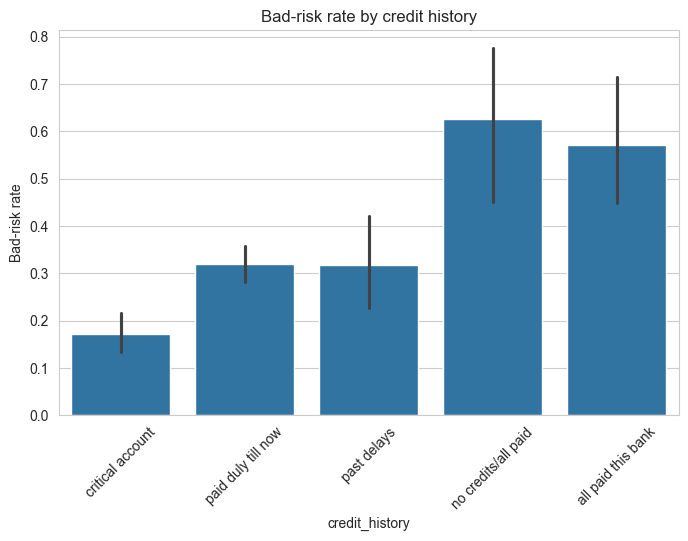

In [127]:
sns.barplot(data=df, x="credit_history", y="risk")
plt.title('Bad-risk rate by credit history')
plt.ylabel('Bad-risk rate')
plt.xticks(rotation=45)
plt.show()

In [128]:
df["credit_history"].value_counts()

credit_history
paid duly till now     530
critical account       293
past delays             88
all paid this bank      49
no credits/all paid     40
Name: count, dtype: int64

There seems to be another **counterintuitive finding**: clients with `critical account` have the *lowest* bad-risk rate, while `no credits/all paid` and `all paid this bank` have the *highest*. The likely explanation: clients with an active, complex credit history are known quantities the bank can assess, whereas those with little or no history are an unknown and the unknown is riskier. The value counts also confirm that `paid duly till now` and `critical account` are the largest groups, which explains the overall 70/30 balance. Naive intuition ("critical account = bad for the bank") is not completely true here.

### Risk across other categorical features

A compact look at four more categorical predictors at once.

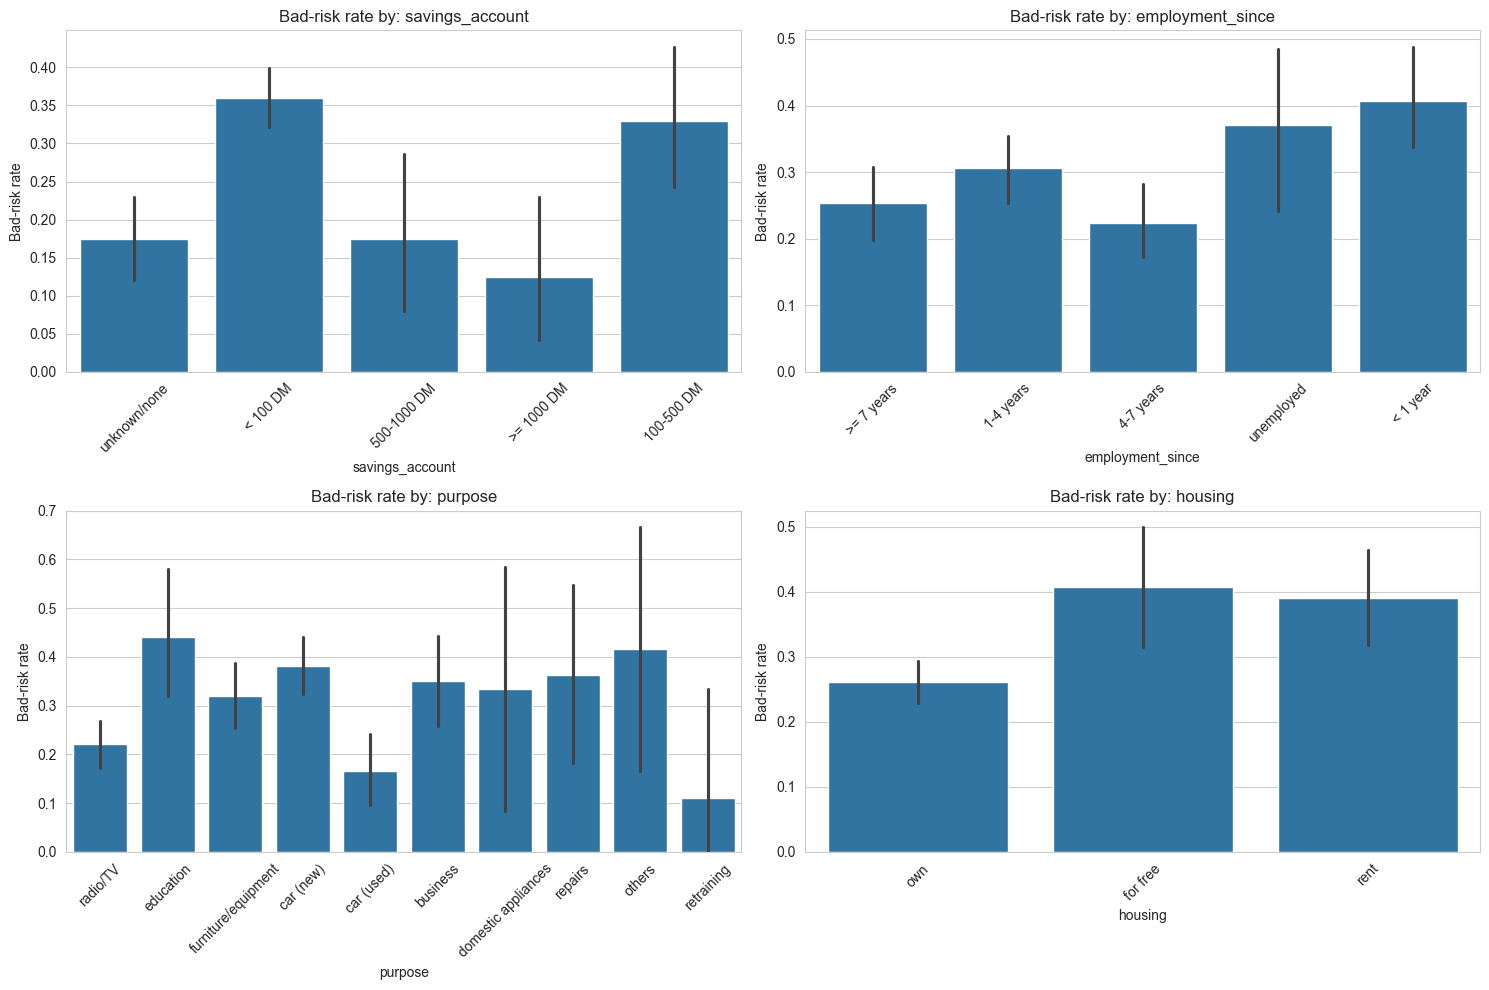

In [129]:
cat_cols = ['savings_account', 'employment_since', 'purpose', 'housing']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(data=df, x=col, y='risk', ax=axes[i])
    axes[i].set_title(f'Bad-risk rate by: {col}')
    axes[i].set_ylabel('Bad-risk rate')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **employment_since**: clear pattern — "unemployed" and "< 1 year" are riskiest; longer employment means lower risk. Job stability matters.
- **housing**: owning ("own") is clearly less risky than renting or living for free. Stability again.
- **savings_account**: the same "unknown/none" thing as credit history, low risk despite the label.
- **purpose**: mixed, as seen in the SQL analysis.

### Descriptive statistics — numerical features

In [130]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable,risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


A few things stand out:

- **Loan duration** averages around 21 months (median 18), ranging from 4 up to 72 months.
- **Credit amount** is where it gets interesting. The average loan is 3,271 DM, but the median is only 2,319 DM and the maximum reaches 18,424 DM. When the mean sits well above the median like this, it usually means the distribution is right-skewed: most loans are fairly small, but a handful of large ones pull the average up.
- **Age** ranges from 19 to 75, averaging around 35, with most clients on the younger side, we already know this.

That skew in credit amount is worth keeping in mind. It could potentially affect models that are sensitive to feature scale, so we'll come back to it when preparing the data for modelling. It's also worth noting that several "numerical" columns (installment_rate, residence_since, existing_credits, people_liable) are really ordinal scales (1–4) rather than truly continuous values.

### Outlier analysis

Only three features are truly continuous (`credit_amount`, `age`, `duration_months`), so I focus the outlier check on those, first visually with boxplots.

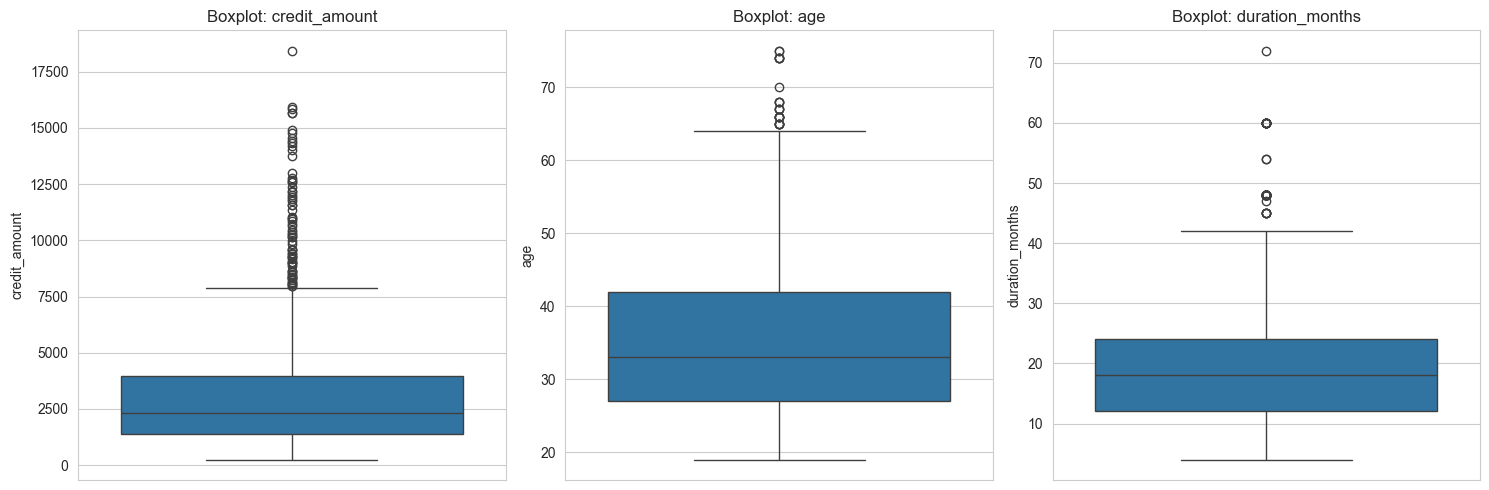

In [131]:
cols = ["credit_amount", "age", "duration_months"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

`credit_amount` clearly has a long tail of high-value outliers (the skew we saw in the numbers), while `age` and `duration_months` have only a few. Next I quantify the `credit_amount` outliers using the IQR method.

In [132]:
Q1 = df['credit_amount'].quantile(0.25)
Q3 = df['credit_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['credit_amount'] < lower_bound) | (df['credit_amount'] > upper_bound)]
print(f"Upper bound: {upper_bound:.0f} DM")
print(f"Number of outliers: {len(outliers)}")
outliers["risk"].value_counts()

Upper bound: 7882 DM
Number of outliers: 72


risk
1    39
0    33
Name: count, dtype: int64

The IQR method flags **72 outliers** (~7% of the data) in `credit_amount`.

The key question isn't *how many* outliers there are, but *whether they're errors or legitimate values*. Here they're probably legitimate. Large loans are a normal part of a bank's business, not data-entry mistakes. More importantly, **39 of the 72 large loans (54%) are bad risks**, nearly double the overall rate of 30%.

That tells me these high-value loans carry real signal about credit risk. Removing them would mean discarding exactly the kind of risky clients the model needs to learn from, so we are keeping them in.

### Correlation between numerical features

Before modelling, it's useful to see how the numerical features relate to each other (and to risk), mainly to check for strong multicollinearity.

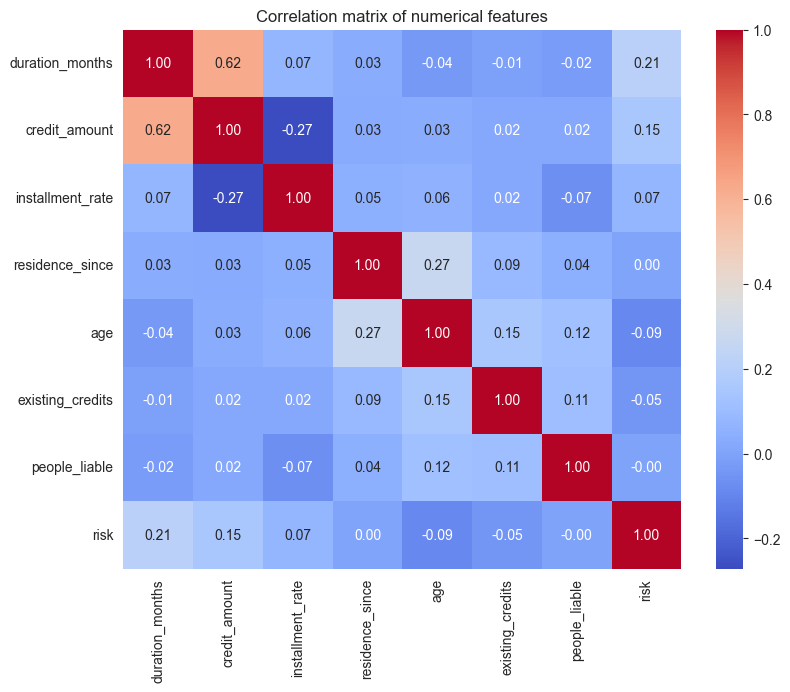

In [133]:
numeric_cols = df.select_dtypes(include="number")
correlation_matrix = numeric_cols.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix of numerical features')
plt.show()

A few notes:

- Several of these features are ordinal scales rather than truly continuous, so their correlations should be read only as a rough indications.
- The strongest relationship is between `credit_amount` and `duration_months` (0.62): bigger loans run longer, which makes sense. At 0.62 this is not high enough to cause multicollinearity problems, and the  models we'll use are robust to correlated features anyway.
- No numerical feature correlates strongly with `risk` (the highest is duration at 0.21). This suggests risk won't be predictable from numerical features alone: the strong predictors are perhaps the categorical ones seen earlier, which makes proper encoding important.

### Numerical features vs. risk

Next, violin plots compare how loan amount and duration are distributed across the two risk groups. (A violin plot shows the full shape of the distribution, wider means more clients at that value, with an embedded mini-boxplot showing the median and quartiles.)

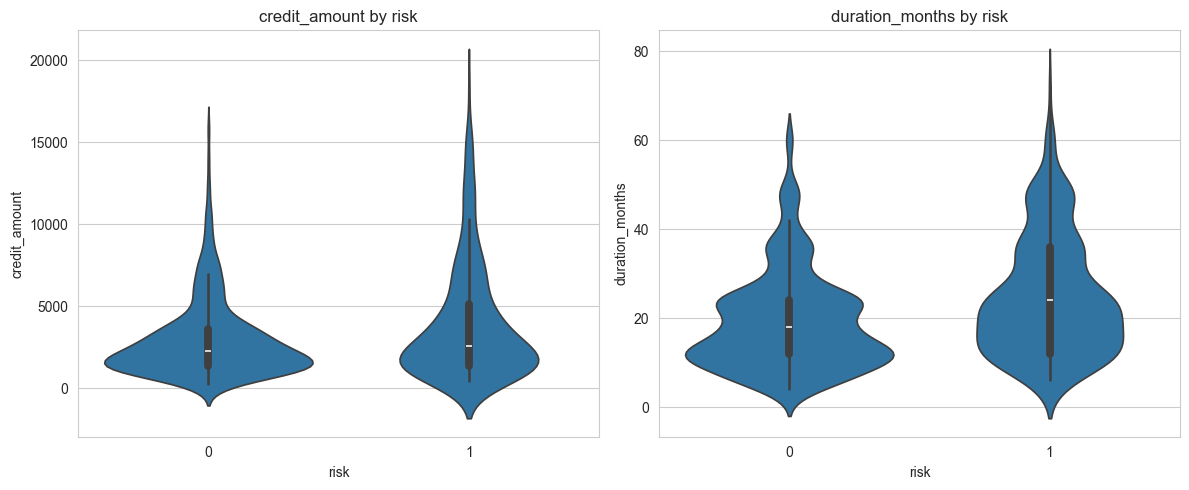

In [134]:
cols = ["credit_amount", "duration_months"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(cols):
    sns.violinplot(data=df, x="risk", y=col, ax=axes[i])
    axes[i].set_title(f'{col} by risk')
plt.tight_layout()
plt.show()

For both features, the bad-risk group (1) sits noticeably higher. Larger loans and longer durations are more common among clients who defaulted. The effect is clearest for duration, which lines up with it being the strongest numerical correlate of risk.

### Loan amount vs. duration, coloured by risk

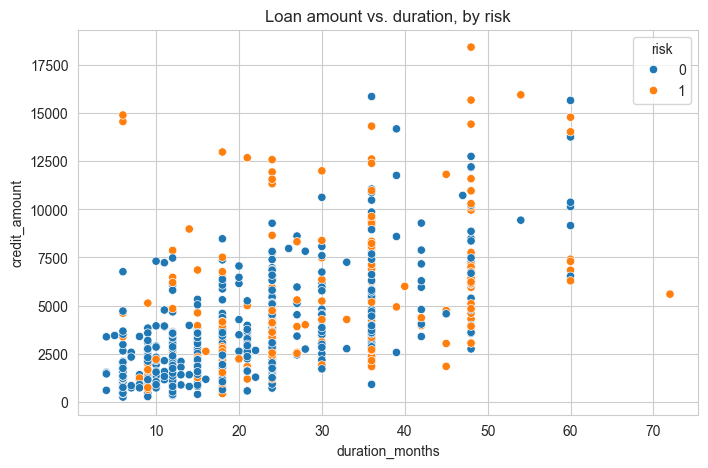

In [135]:
sns.scatterplot(data=df, x="duration_months", y="credit_amount", hue="risk")
plt.title('Loan amount vs. duration, by risk')
plt.show()

A few patterns stand out:

- The bottom-left corner meaning small, short loans is mostly low-risk (blue).
- Bad risks (orange) become somewhat more frequent toward larger and longer loans (top and right).
- There's a clear diagonal trend, reflecting the correlation between amount and duration.

That said, the two groups overlap heavily, there's no clean "risky zone" that separates good from bad based on these two variables alone. This is an important takeaway: predicting risk will require a model that combines many features together, rather than relying on any single pair.

## EDA — Summary

A few key takeaways from the exploration that shaped how I approached the modelling:

**Data quality.** The dataset is clean: 1,000 clients, no missing values, no obvious errors. The target is imbalanced at roughly 70/30 (good vs. bad risk), which is something to keep in mind when evaluating models, since plain accuracy can be misleading.

**What drives risk.** The strongest signals come from the categorical features: checking account status, credit history, employment length, and housing. Among the numerical features, loan duration and credit amount show the clearest link to risk (larger and longer loans tend to be riskier).

**A counterintuitive finding.** Credit history didn't behave as expected: clients with "no credits / all paid" were actually riskier than those with a "critical account". The likely explanation is that clients with an active credit history are known quantities to the bank, whereas those without one are harder to assess.

**Implication for modelling.** No single feature or simple pair cleanly separates good from bad risk. This means a model that combines many features together is needed, rather than a few hand-picked rules. 


## 4. Preparing the data for modelling

Now we move toward prediction. The plan for the rest of the notebook:

1. **Split** the data into a training and a test set. The test set is locked away until the very end.
2. **Preprocess** the features (encoding, scaling), with separate pipelines for different model families.
3. **Screen six classifiers** with cross-validation, then tune each one.
4. **Test whether SMOTE** (synthetic oversampling) beats class weighting as a strategy for the 70/30 imbalance.
5. **Select the final model using the business cost matrix** and tune its decision threshold accordingly.
6. **Evaluate once on the test set**, interpret the model, and translate the findings into business terms.


### Train/test split

All columns except `risk` are features. We split off 20% as a held-out test set; `stratify=y` keeps the 70/30 class ratio identical in both parts. With an imbalanced target, a purely random split could leave the test set with a distorted share of bad risks.

In [136]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="risk")
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=99, stratify=y
)
X_train.shape, X_test.shape

((800, 20), (200, 20))

### Feature types

The features fall into three groups, and each group needs different treatment:

- **Nominal** — categories with no natural order (`purpose`, `housing`, ...). These go to one-hot encoding. The group also includes categoricals that are *mostly* ordered but contain a category that breaks the scale: `checking_account` orders by balance, but "no account" doesn't fit on that scale, and the same goes for "unknown/none" in `savings_account`. One-hot encoding lets the models treat each category independently instead of forcing a false order on them.
- **Ordinal** — numeric 1–4 scales that are already meaningfully ordered; they stay numeric.
- **Continuous** — true measurements: `duration_months`, `credit_amount`, `age`.

In [137]:

nominal = ['purpose', 'personal_status_sex', 'other_debtors',
           'property', 'other_installment', 'housing', 'job',
           'telephone', 'foreign_worker', 'checking_account',
           'savings_account', 'employment_since', 'credit_history']


ordinal = ['installment_rate', 'residence_since', 'existing_credits', 'people_liable']


continuous = ['duration_months', 'credit_amount', 'age']

### Two preprocessing pipelines

The six classifiers we'll compare don't all want the same input:

- **Tree-based models** (Decision Tree, Random Forest, XGBoost) split on one feature at a time, so feature scale and skew don't affect them. They only need the categoricals encoded: `preprocessor_tree` one-hot encodes the nominals and passes the numeric columns through untouched. A side benefit: split thresholds stay in raw, readable units (months, DM), which will pay off when we visualise the tree later.
- **Linear and distance-based models** (Logistic Regression, SVM, KNN) are sensitive to scale: without standardisation, `credit_amount` (hundreds to thousands of DM) would dominate features measured on a 1–4 scale. `preprocessor_scaled` therefore log-transforms and standardises the continuous features, and standardises the ordinal ones. The log tackles the strong right skew found in `credit_amount` during the EDA (and milder skew in duration).

In both pipelines the encoder uses `drop='first'`: keeping all *k* dummies of a *k*-category feature alongside an intercept makes them perfectly collinear, which breaks the linear models. Trees wouldn't mind either way, but one shared encoding keeps the feature space identical across model families.

In [138]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal)
    ],
    remainder='passthrough'
)

continuous_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log, feature_names_out='one-to-one')),
    ('scale', StandardScaler())
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cont', continuous_transformer, continuous),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal),
        ('ord', StandardScaler(), ordinal)
    ],
    remainder='passthrough'
)

## 5. Modelling

### Setup: models, imbalance strategy, evaluation

**Models.** Six classifiers spanning different families: Logistic Regression (linear baseline), Decision Tree, Random Forest and XGBoost (tree ensembles), SVM and KNN (kernel / distance based).

**Class imbalance.** With a 70/30 target, an untreated model could try to play it safe and over-predict "good". But for a bank, missing a bad risk is usually the more expensive mistake. We therefore weight the minority class up during training with `class_weight='balanced'`, which makes both classes contribute equally to the loss. Two models need special handling:

- XGBoost has no `class_weight` parameter; its equivalent is `scale_pos_weight`, set to the good/bad ratio in the training data (≈ 2.33).
- KNN has no class weighting mechanism at all, it is a pure distance method, so it runs as-is here and gets its imbalance treatment later, in the SMOTE comparison.

**Evaluation.** The primary screening metric is **ROC AUC**: it measures how well a model *ranks* clients by risk, independent of any decision threshold, and it is not fooled by imbalance the way accuracy is. Recall and precision are tracked alongside, but for now they are context, not selection criteria.

Cross-validation uses **stratified** 5-fold splits, so every fold keeps the 70/30 ratio, and we report the standard deviation across folds next to every mean becouse without it there is no way to tell whether a difference between two models is real or just fold-to-fold noise.

In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ['roc_auc', 'recall', 'precision', 'f1', 'accuracy']

# XGBoost's equivalent of class_weight='balanced'
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # good/bad ratio, ~2.33

In [140]:
models = {
    'LogReg (balanced)': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=5000, solver='saga', random_state=SEED))
    ]),
    'Decision Tree (balanced)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=SEED))
    ]),
    'RF (balanced)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=SEED))
    ]),
    'SVM (balanced)': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', SVC(class_weight='balanced', random_state=SEED))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('classifier', KNeighborsClassifier())
    ]),
    'XGB (balanced)': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('classifier', XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=SEED))
    ])
}

### Baseline screening — default hyperparameters

All six models first run with default hyperparameters. This baseline serves two purposes: it sketches the performance landscape, and once we tune it shows how much of each model's performance the defaults were already capturing.

In [141]:
records = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for m in scoring:
        row[m] = res[f'test_{m}'].mean()
        row[f'{m}_std'] = res[f'test_{m}'].std()
    records.append(row)

results_df = pd.DataFrame(records).set_index('model').sort_values('roc_auc', ascending=False)
results_df.round(3)

,roc_auc,roc_auc_std,recall,recall_std,precision,precision_std,f1,f1_std,accuracy,accuracy_std
model,,,,,,,,,,
SVM (balanced),0.798,0.035,0.688,0.044,0.535,0.060,0.600,0.045,0.722,0.043
RF (balanced),0.792,0.036,0.308,0.069,0.664,0.064,0.418,0.072,0.746,0.022
XGB (balanced),0.775,0.031,0.550,0.081,0.577,0.039,0.559,0.046,0.742,0.020
LogReg (balanced),0.775,0.054,0.688,0.095,0.504,0.065,0.579,0.065,0.700,0.051
KNN,0.715,0.042,0.379,0.091,0.627,0.064,0.467,0.082,0.746,0.025
Decision Tree (balanced),0.655,0.015,0.525,0.052,0.514,0.024,0.518,0.024,0.707,0.014


The table splits into three performance tiers:

- **~0.77–0.80:** SVM, Random Forest, XGBoost and Logistic Regression. The differences between them sit within one fold-to-fold standard deviation, so the top group is effectively a tie.
- **~0.72:** KNN — distance metrics struggle in the ~48-dimensional one-hot feature space.
- **~0.66:** the single Decision Tree, which with no depth limit overfits each training fold and pays for it in validation.

Two details worth noting. Logistic Regression, the simplest model here, sits right in the top group. On tabular credit data, linear models can compete with far more complex ones. And the recall column shows Random Forest ranking clients well (high AUC) but catching only a third of bad risks at the default 0.5 threshold smething that will get its own treatment later.

### Hyperparameter tuning

Each model is tuned with `GridSearchCV`, selecting by cross-validated ROC AUC (`refit='roc_auc'`) while recording the remaining metrics for the chosen configuration. Two working rules shaped the grids:

- If a parameter's best value lands on the *edge* of its grid, the grid gets extended in that direction, unless the parameter is one where more is monotonically better up to a plateau (like the number of trees in a Random Forest), where chasing the edge buys nothing.
- Improvements smaller than the fold-to-fold standard deviation are treated as noise, not progress.

A short note before each grid explains which knobs are being turned and why.

**Logistic Regression** has essentially two knobs: `C`, the inverse regularisation strength (smaller = coefficients shrunk harder toward zero), and the penalty type (`l2` shrinks all coefficients, `l1` can zero some out entirely).

In [142]:
logreg_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__l1_ratio': [0, 0.5, 1]   # 0 = ridge (l2), 1 = lasso (l1), 0.5 = mix
    
}

grid_logreg = GridSearchCV(
    models['LogReg (balanced)'],
    logreg_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

best_idx = grid_logreg.best_index_
print("Best params:", grid_logreg.best_params_)
print(f"Best CV ROC AUC: {grid_logreg.best_score_:.3f} "
      f"(+/- {grid_logreg.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__C': 0.1, 'classifier__l1_ratio': 0}
Best CV ROC AUC: 0.781 (+/- 0.049)


**Decision Tree** — the tuning here is mostly about restraining growth: `max_depth` (the main lever against overfitting), `min_samples_leaf` and `min_samples_split`.

In [143]:
dt_grid = {
    'classifier__max_depth': [3, 4, 5, 6, 8, 10],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__min_samples_split': [2, 10, 20]
}

grid_dt = GridSearchCV(
    models['Decision Tree (balanced)'],
    dt_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

best_idx = grid_dt.best_index_
print("Best params:", grid_dt.best_params_)
print(f"Best CV ROC AUC: {grid_dt.best_score_:.3f} "
      f"(+/- {grid_dt.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
Best CV ROC AUC: 0.736 (+/- 0.040)


**Random Forest** averages many deep, decorrelated trees. `max_features` is the heart of it — fewer candidate features per split makes the trees more different from each other, and that diversity is what makes averaging work. `n_estimators` is a plateau parameter (more trees never hurt, they just stop helping), and unlike a single tree, a forest can afford unlimited depth because averaging cancels out the variance.

In [144]:
rf_grid = {
    'classifier__n_estimators': [200, 400, 600],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__bootstrap': [True, False],
    'classifier__criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(
    models['RF (balanced)'],
    rf_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_idx = grid_rf.best_index_
print("Best params:", grid_rf.best_params_)
print(f"Best CV ROC AUC: {grid_rf.best_score_:.3f} "
      f"(+/- {grid_rf.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__bootstrap': True, 'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 600}
Best CV ROC AUC: 0.803 (+/- 0.036)


**SVM** — `C` controls how hard the margin penalises misclassification; `gamma` sets the reach of the RBF kernel (small = smooth boundary, large = wiggly). Several kernel shapes are compared, although RBF with tuned `C` and `gamma` already spans the range from nearly linear to highly curved boundaries.

In [145]:
svm_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 0.01, 0.1, 1, 'auto'],
    'classifier__kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

grid_svm = GridSearchCV(
    models['SVM (balanced)'],
    svm_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)

best_idx = grid_svm.best_index_
print("Best params:", grid_svm.best_params_)
print(f"Best CV ROC AUC: {grid_svm.best_score_:.3f} "
      f"(+/- {grid_svm.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best CV ROC AUC: 0.798 (+/- 0.035)


**XGBoost** builds trees *sequentially*, each new tree correcting the errors of the ensemble so far, so its levers differ from a forest's. `learning_rate` (how much each tree contributes) trades off against `n_estimators`; unlike in a forest, too many boosting rounds at a high learning rate can overfit. `max_depth` keeps individual trees weak, and `subsample` / `colsample_bytree` add stochastic regularisation. 

In [146]:
xgb_grid = {
    'classifier__n_estimators': [100, 200, 400, 600],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': [0.01, 0.03, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    models['XGB (balanced)'],
    xgb_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

best_idx = grid_xgb.best_index_
print("Best params:", grid_xgb.best_params_)
print(f"Best CV ROC AUC: {grid_xgb.best_score_:.3f} "
      f"(+/- {grid_xgb.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.03, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best CV ROC AUC: 0.799 (+/- 0.039)


**KNN** — `n_neighbors` is the main lever (small k = flexible but noisy boundary, large k = smooth), `weights='distance'` lets closer neighbours count more, and `p` switches between Manhattan (p=1) and Euclidean (p=2) distance.

In [147]:
knn_grid = {
    'classifier__n_neighbors': [3, 5, 7, 11, 15, 21, 31],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]
}

grid_knn = GridSearchCV(
    models['KNN'],
    knn_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

best_idx = grid_knn.best_index_
print("Best params:", grid_knn.best_params_)
print(f"Best CV ROC AUC: {grid_knn.best_score_:.3f} "
      f"(+/- {grid_knn.cv_results_['std_test_roc_auc'][best_idx]:.3f})")

Best params: {'classifier__n_neighbors': 31, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best CV ROC AUC: 0.778 (+/- 0.033)


### Tuned results and the effect of tuning

For each model we pull the full metric row of its AUC-optimal configuration (recorded during the grid search), then compare tuned AUC against the baseline.

In [148]:
def tuned_row(grid, name):
    i = grid.best_index_
    row = {'model': name}
    for m in scoring:
        row[m] = grid.cv_results_[f'mean_test_{m}'][i]
        row[f'{m}_std'] = grid.cv_results_[f'std_test_{m}'][i]
    return row

tuned_df = pd.DataFrame([
    tuned_row(grid_logreg, 'LogReg (balanced)'),
    tuned_row(grid_dt,     'Decision Tree (balanced)'),
    tuned_row(grid_rf,     'RF (balanced)'),
    tuned_row(grid_svm,    'SVM (balanced)'),
    tuned_row(grid_xgb,    'XGB (balanced)'),
    tuned_row(grid_knn,    'KNN'),
]).set_index('model').sort_values('roc_auc', ascending=False)

tuned_df.round(3)

,roc_auc,roc_auc_std,recall,recall_std,precision,precision_std,f1,f1_std,accuracy,accuracy_std
model,,,,,,,,,,
RF (balanced),0.803,0.036,0.529,0.092,0.587,0.073,0.553,0.076,0.746,0.038
XGB (balanced),0.799,0.039,0.617,0.064,0.551,0.036,0.580,0.033,0.732,0.022
SVM (balanced),0.798,0.035,0.688,0.044,0.535,0.060,0.600,0.045,0.722,0.043
LogReg (balanced),0.781,0.049,0.712,0.036,0.521,0.059,0.600,0.040,0.712,0.045
KNN,0.778,0.033,0.225,0.020,0.750,0.079,0.345,0.024,0.744,0.010
Decision Tree (balanced),0.736,0.040,0.800,0.031,0.451,0.044,0.576,0.042,0.644,0.057


In [149]:
comparison = pd.DataFrame({
    'auc_base':  results_df['roc_auc'],
    'auc_tuned': tuned_df['roc_auc'],
})
comparison['delta'] = comparison['auc_tuned'] - comparison['auc_base']
comparison.sort_values('auc_tuned', ascending=False).round(3)

,auc_base,auc_tuned,delta
model,,,
RF (balanced),0.792,0.803,0.011
XGB (balanced),0.775,0.799,0.024
SVM (balanced),0.798,0.798,0.000
LogReg (balanced),0.775,0.781,0.006
KNN,0.715,0.778,0.063
Decision Tree (balanced),0.655,0.736,0.081


**The gains follow a pattern: tuning helps in proportion to how bad the defaults were.** The Decision Tree gained the most (+0.08 — its default unlimited depth was a big problem), KNN next (+0.06 — the default k=5 is far too low in this feature space; the best configuration, k=31 with Manhattan distance, smooths the boundary). XGBoost, Random Forest and Logistic Regression were already near their optimum, and SVM's best configuration *is* the sklearn default, a useful reminder that tuning's job is to verify the defaults, not to beat them by force.

**The top of the table remains a statistical tie.** RF (~0.80), XGB and SVM sit within ~0.005 of each other with fold-to-fold deviations around 0.035, so no model can claim the lead on AUC alone. The selection needs a sharper criterion and it arrives in section 6.

### An alternative imbalance strategy: SMOTE

Class weighting tells the model to *care more* about the existing bad-risk cases. **SMOTE** (Synthetic Minority Oversampling Technique) takes the opposite route: it generates synthetic minority samples by interpolating between real ones, so the model trains on a balanced dataset. For a bank focused on catching bad risks, it is worth testing whether this performs better.

Two implementation details matter:

- SMOTE works *inside* the cross-validation pipeline (`imblearn`'s pipeline), after preprocessing and before the model. Each CV fold then oversamples only its own training part, and the validation fold stays untouched. Oversampling before the split would cause data leak.
- The SMOTE models use **no class weighting**. SMOTE and `class_weight` are both training-time balancers; stacking them would over-correct toward the minority class. One or the other, never both.

The procedure mirrors the previous section exactly: the same six models, the same CV, the same grids — first with defaults, then tuned.

In [150]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_models = {
    'LogReg (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', LogisticRegression(max_iter=5000, solver='saga', random_state=SEED))
    ]),
    'Decision Tree (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', DecisionTreeClassifier(random_state=SEED))
    ]),
    'RF (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', RandomForestClassifier(random_state=SEED))
    ]),
    'SVM (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', SVC(random_state=SEED))
    ]),
    'KNN (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', KNeighborsClassifier())
    ]),
    'XGB (SMOTE)': ImbPipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('smote', SMOTE(random_state=SEED)),
        ('classifier', XGBClassifier(random_state=SEED))
    ])
}

In [151]:
records_smote = []
for name, pipe in smote_models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for m in scoring:
        row[m] = res[f'test_{m}'].mean()
        row[f'{m}_std'] = res[f'test_{m}'].std()
    records_smote.append(row)

results_smote_df = pd.DataFrame(records_smote).set_index('model').sort_values('roc_auc', ascending=False)
results_smote_df.round(3)

,roc_auc,roc_auc_std,recall,recall_std,precision,precision_std,f1,f1_std,accuracy,accuracy_std
model,,,,,,,,,,
XGB (SMOTE),0.785,0.038,0.517,0.068,0.626,0.080,0.563,0.059,0.760,0.033
SVM (SMOTE),0.782,0.040,0.600,0.066,0.539,0.063,0.566,0.059,0.724,0.042
RF (SMOTE),0.781,0.035,0.392,0.061,0.604,0.051,0.471,0.048,0.739,0.018
LogReg (SMOTE),0.771,0.058,0.667,0.092,0.512,0.074,0.577,0.071,0.706,0.053
KNN (SMOTE),0.720,0.042,0.725,0.036,0.435,0.036,0.543,0.035,0.632,0.040
Decision Tree (SMOTE),0.604,0.030,0.450,0.045,0.445,0.040,0.447,0.040,0.666,0.026


At default settings SMOTE does not improve ranking quality anywhere it matters: SVM, RF and the Decision Tree get worse, LogReg and KNN move within noise, and only XGBoost improves slightly. Tuning gets a fair chance to change that. For simplicity, the same grids as before, run in a single loop.

In [152]:
smote_grids = {}
smote_param_grids = {
    'LogReg (SMOTE)':        logreg_grid,
    'Decision Tree (SMOTE)': dt_grid,
    'RF (SMOTE)':            rf_grid,
    'SVM (SMOTE)':           svm_grid,
    'XGB (SMOTE)':           xgb_grid,
    'KNN (SMOTE)':           knn_grid,
}

for name, param_grid in smote_param_grids.items():
    g = GridSearchCV(smote_models[name], param_grid, cv=cv,
                     scoring=scoring, refit='roc_auc', n_jobs=-1)
    g.fit(X_train, y_train)
    smote_grids[name] = g
    i = g.best_index_
    print(f"{name:25s} best CV ROC AUC: {g.best_score_:.3f} "
          f"(+/- {g.cv_results_['std_test_roc_auc'][i]:.3f})")

LogReg (SMOTE)            best CV ROC AUC: 0.778 (+/- 0.051)
Decision Tree (SMOTE)     best CV ROC AUC: 0.723 (+/- 0.040)
RF (SMOTE)                best CV ROC AUC: 0.796 (+/- 0.037)
SVM (SMOTE)               best CV ROC AUC: 0.785 (+/- 0.046)
XGB (SMOTE)               best CV ROC AUC: 0.798 (+/- 0.040)
KNN (SMOTE)               best CV ROC AUC: 0.770 (+/- 0.030)


In [153]:
tuned_smote_df = pd.DataFrame(
    [tuned_row(g, name) for name, g in smote_grids.items()]
).set_index('model').sort_values('roc_auc', ascending=False)

tuned_smote_df.round(3)

,roc_auc,roc_auc_std,recall,recall_std,precision,precision_std,f1,f1_std,accuracy,accuracy_std
model,,,,,,,,,,
XGB (SMOTE),0.798,0.040,0.517,0.087,0.595,0.064,0.548,0.060,0.747,0.028
RF (SMOTE),0.796,0.037,0.412,0.053,0.637,0.058,0.499,0.050,0.753,0.023
SVM (SMOTE),0.785,0.046,0.683,0.077,0.533,0.053,0.598,0.058,0.725,0.040
LogReg (SMOTE),0.778,0.051,0.679,0.070,0.503,0.058,0.576,0.052,0.699,0.045
KNN (SMOTE),0.770,0.030,0.650,0.055,0.500,0.032,0.563,0.020,0.698,0.024
Decision Tree (SMOTE),0.723,0.040,0.521,0.120,0.497,0.042,0.505,0.074,0.700,0.031


### Strategy comparison: class weighting vs SMOTE

One summary table: AUC of every model under both strategies, before and after tuning.

In [154]:
def base_name(s):
    return s.replace(' (balanced)', '').replace(' (SMOTE)', '').strip()

summary = {}
for label, frame in [('balanced_base', results_df), ('balanced_tuned', tuned_df),
                     ('smote_base', results_smote_df), ('smote_tuned', tuned_smote_df)]:
    s = frame['roc_auc'].copy()
    s.index = [base_name(i) for i in s.index]
    summary[label] = s

strategy_compare = pd.DataFrame(summary).sort_values('balanced_tuned', ascending=False)
strategy_compare.round(3)

,balanced_base,balanced_tuned,smote_base,smote_tuned
RF,0.792,0.803,0.781,0.796
XGB,0.775,0.799,0.785,0.798
SVM,0.798,0.798,0.782,0.785
LogReg,0.775,0.781,0.771,0.778
KNN,0.715,0.778,0.720,0.770
Decision Tree,0.655,0.736,0.604,0.723


Even after tuning, SMOTE wins **nowhere**: for every model the class-weighted version is equal or better on AUC. In hindsight this makes sense: SMOTE's real effect is to shift *where* a model draws its decision line (more aggressive flagging of the minority class), not how well it *ranks* clients, and ranking is what AUC measures. Since the decision line is exactly what the next section sets directly, using the actual business costs instead of synthetic data, the class-weighted models go forward.

## 6. Choosing the final model — by cost, not by AUC alone

"The best model" is a vague phrase: best at *what*? AUC produced a shortlist, but the top three are statistically tied and AUC weights all errors equally, which a bank explicitly does not. Luckily, the dataset ships with an official cost matrix:

| | predicted good | predicted bad |
|---|---|---|
| **actual good** | 0 | 1 |
| **actual bad** | **5** | 0 |

Missing a bad risk (a false negative) costs **five times** more than refusing a good client (a false positive). That asymmetry *is* the business objective, so it becomes the selection criterion directly: **the final model is the one with the lowest expected cost at its own optimal decision threshold.**

The procedure, for each tuned model:

1. Get an honest probability for every training client via `cross_val_predict` — out-of-fold (OOF) predictions, meaning each client is scored by a model that never saw them during training. The test set stays untouched.
2. Sweep thresholds from 0.01 to 0.99; at each one, count the errors and compute `cost = 5·FN + 1·FP`.
3. Keep the threshold with the lowest total cost.

Note that the two interventions answer different questions: class weighting during training shapes *what the model learns* from an imbalanced sample, while the cost-based threshold sets *where we act* on its predictions. Expect the optimal thresholds to land well below 0.5. With false negatives this expensive, it pays to flag a client as risky even for the sake of losing precision.

In [155]:
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import confusion_matrix

# SVC was trained with probability=False (not needed for AUC);
# the threshold scan needs predict_proba, so flip it on for a clone
svm_proba = clone(grid_svm.best_estimator_).set_params(classifier__probability=True)

candidates = {
    'LogReg':        grid_logreg.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'RF':            grid_rf.best_estimator_,
    'SVM':           svm_proba,
    'XGB':           grid_xgb.best_estimator_,
    'KNN':           grid_knn.best_estimator_,
}

COST_FN, COST_FP = 5, 1
thresholds = np.arange(0.01, 1.00, 0.01)

def cost_at_best_threshold(model, X, y, cv):
    """Out-of-fold probabilities -> sweep thresholds -> return the cheapest operating point."""
    proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]  # P(bad)
    best = None
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
        cost = COST_FN * fn + COST_FP * fp
        if best is None or cost < best['cost']:
            best = {
                'threshold': round(t, 2), 'cost': cost,
                'recall': tp / (tp + fn) if (tp + fn) else 0,
                'precision': tp / (tp + fp) if (tp + fp) else 0,
                'FN': fn, 'FP': fp
            }
    return best

cost_df = pd.DataFrame(
    {name: cost_at_best_threshold(m, X_train, y_train, cv) for name, m in candidates.items()}
).T.sort_values('cost')

cost_df

,threshold,cost,recall,precision,FN,FP
RF,0.29,387.0,0.904167,0.443763,23.0,272.0
SVM,0.12,403.0,0.954167,0.396880,11.0,348.0
KNN,0.20,403.0,0.912500,0.423598,21.0,298.0
XGB,0.14,404.0,0.950000,0.398601,12.0,344.0
LogReg,0.36,412.0,0.870833,0.448498,31.0,257.0
Decision Tree,0.21,450.0,0.891667,0.400749,26.0,320.0


**Random Forest wins** with the lowest expected cost and since it also led the AUC table, the two criteria agree and the choice is clean. The mechanics behind the numbers are worth a look:

- All optimal thresholds land between roughly 0.12 and 0.36, far below the default 0.5. Recall on bad risks jumps to 0.87–0.95 across the board.
- The models trade FN against FP differently. SVM and XGBoost push the threshold very low, catch a couple more bad risks but pay with ~345 false alarms; RF stays more selective (threshold 0.29), still catches ~90% of bad risks while raising far fewer false alarms: the cheapest balance overall.
- Logistic Regression confirms its role as the honest baseline: a cost within ~5% of the winner, with full interpretability. If the bank insisted on a fully transparent model, the price would be small.

## 7. Final evaluation on the held-out test set

The test set now gets its single use and it tells us how well the model generalises.

In [156]:
from sklearn.metrics import classification_report, roc_auc_score

# The winner (already fitted on the full training set) and its cost-optimal OOF threshold
winner = grid_rf.best_estimator_
best_threshold = cost_df.loc['RF', 'threshold']

# Probabilities on the test set + decisions at our threshold
proba_test = winner.predict_proba(X_test)[:, 1]   # P(bad)
y_pred = (proba_test >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
cost = COST_FN * fn + COST_FP * fp

print(f"Threshold:          {best_threshold}")
print(f"Test ROC AUC:       {roc_auc_score(y_test, proba_test):.3f}")
print("Confusion matrix:")
print(f"   [[TN {tn:3d}   FP {fp:3d}]")
print(f"    [FN {fn:3d}   TP {tp:3d}]]")
print(f"Cost (5*FN + 1*FP): {cost}")
print()
print(classification_report(y_test, y_pred, target_names=['good', 'bad']))

Threshold:          0.29
Test ROC AUC:       0.789
Confusion matrix:
   [[TN  74   FP  66]
    [FN  10   TP  50]]
Cost (5*FN + 1*FP): 116

              precision    recall  f1-score   support

        good       0.88      0.53      0.66       140
         bad       0.43      0.83      0.57        60

    accuracy                           0.62       200
   macro avg       0.66      0.68      0.61       200
weighted avg       0.75      0.62      0.63       200



And the before/after view — what the cost-based threshold buys compared with the default 0.5 cutoff:

In [157]:
print(f"{'threshold':>22s} | recall |  FN |  FP | cost")
for t, label in [(0.5, 'default 0.5'), (best_threshold, f'cost-optimal {best_threshold}')]:
    yp = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0, 1]).ravel()
    print(f"{label:>22s} | {tp/(tp+fn):.3f}  | {fn:3d} | {fp:3d} | {COST_FN*fn + COST_FP*fp}")

             threshold | recall |  FN |  FP | cost
           default 0.5 | 0.500  |  30 |  15 | 165
     cost-optimal 0.29 | 0.833  |  10 |  66 | 116


**The model generalises.** Test AUC of 0.789 against a CV estimate of 0.803 — a small, expected drop (CV estimates carry a mild optimistic bias because hyperparameters were chosen on those same folds), with no major sign of overfitting.

**The threshold does its job.** At the default 0.5 cutoff the model would catch only half the bad risks (30 missed, at cost 5 each); at the cost-optimal 0.29 it catches 50 of 60 (83% recall) and total cost drops from 165 to 116, roughly 30% cheaper. The trade: 66 good clients flagged as risky, up from 15. But the math favours it clearly: avoiding 20 expensive misses (−100) buys 51 cheap false alarms (+51).


## 8. Interpretation — why the model flags whom it flags

A strong prediction is half the job. The bank also needs to know *why* a client gets flagged: both to trust the model and to act on its signals. A Random Forest is not directly readable the way a single tree is, so we approach the "why" from several angles and check that they agree: the forest's own feature importances, SHAP values, the decision rules of the tuned single tree, and the odds ratios of the logistic regression.

### Built-in feature importances

The forest's `feature_importances_` measure how much each feature contributes to reducing impurity across all splits. The values sum to 1, so with ~48 columns the average is ~0.02 and anything near 0.1 is a heavyweight. The ranking is a useful first look, but it carries three known distortions:

- **No direction** — it says a feature matters, not which way it pushes the risk.
- **A bias toward continuous features** — `credit_amount`, `duration` and `age` offer many possible split points and collect inflated credit for it.
- **One-hot fragmentation** — a strong categorical like `checking_account` is spread across several dummy columns, so its collective importance is diluted.

                        feature  importance
                  credit_amount      0.1039
                duration_months      0.0931
                            age      0.0880
    checking_account_no account      0.0846
        checking_account_< 0 DM      0.0480
               installment_rate      0.0348
                residence_since      0.0308
       savings_account_< 100 DM      0.0299
credit_history_critical account      0.0277
   savings_account_unknown/none      0.0243
         other_installment_none      0.0219
           property_real estate      0.0194
               existing_credits      0.0193
              purpose_car (new)      0.0190
             purpose_car (used)      0.0175


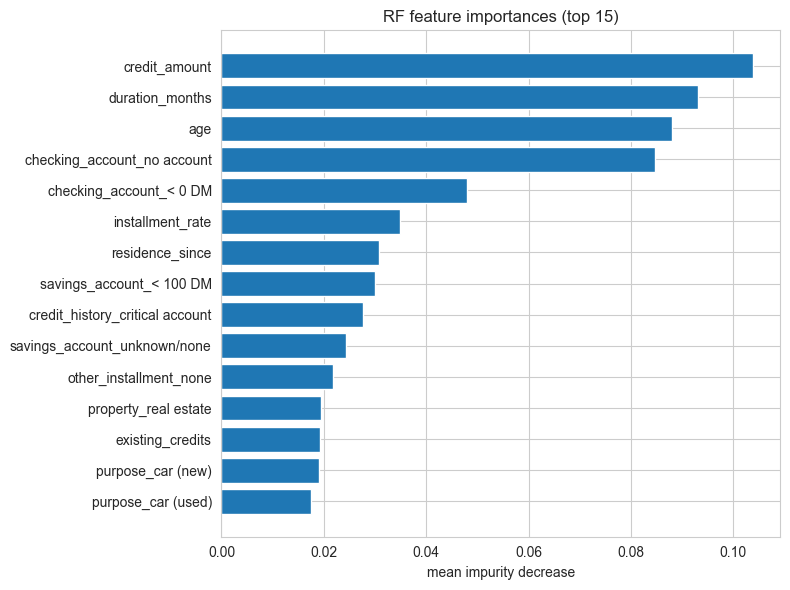

In [158]:
rf = grid_rf.best_estimator_
feat_names = rf.named_steps['preprocessor'].get_feature_names_out()
clean = [f.replace('cat__', '').replace('remainder__', '') for f in feat_names]
importances = rf.named_steps['classifier'].feature_importances_

importance_df = (pd.DataFrame({'feature': clean, 'importance': importances})
                 .sort_values('importance', ascending=False))
print(importance_df.head(15).round(4).to_string(index=False))

top = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top['feature'], top['importance'])
plt.title('RF feature importances (top 15)')
plt.xlabel('mean impurity decrease')
plt.tight_layout()
plt.show()

The chart reflects all three caveats at once: the continuous trio tops the list, with the checking-account dummies right behind it. SHAP should give a cleaner picture.

### SHAP values

SHAP attributes each individual prediction to the features that produced it. It fixes both missing pieces: a less biased global importance ranking (bar chart) and, crucially, **direction** (beeswarm). In the beeswarm, every dot is one test-set client; a position right of zero pushes that client's prediction toward *bad*, left toward *good*; red means a high feature value (for dummies: the category applies), blue a low one.

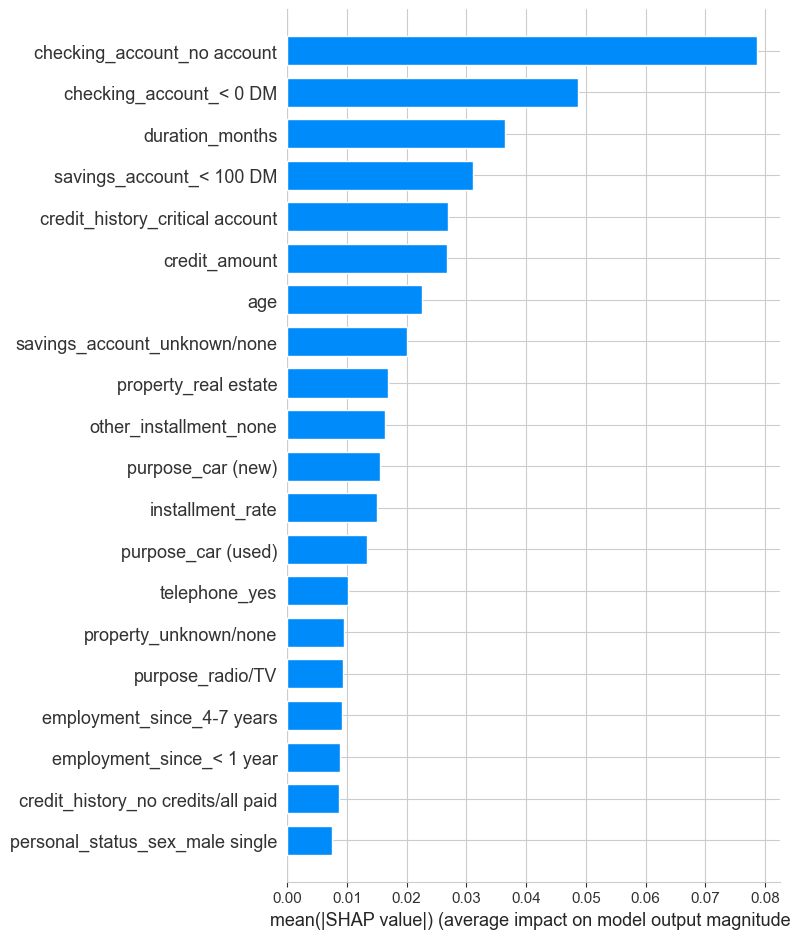

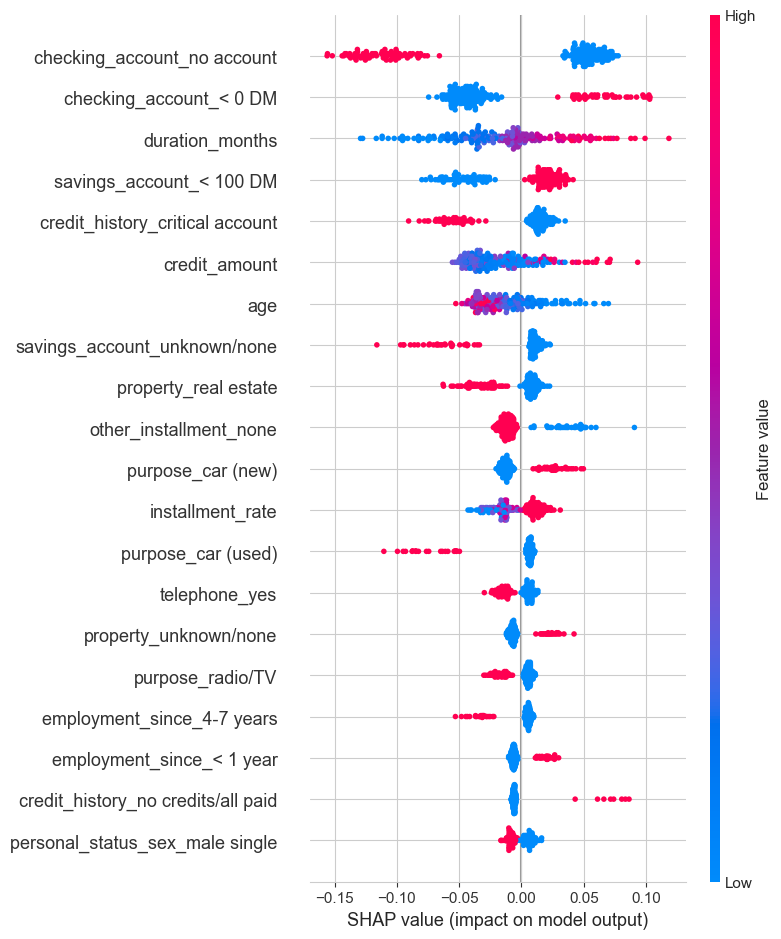

In [159]:
import shap

preprocessor = rf.named_steps['preprocessor']
model = rf.named_steps['classifier']

# SHAP needs the data exactly as the model sees it (after preprocessing)
X_test_trans = preprocessor.transform(X_test)
if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans)

# Binary RF: shap returns either a list [class0, class1] or a 3D array (n, features, classes)
if isinstance(shap_values, list):
    sv_bad = shap_values[1]
else:
    sv_bad = shap_values[..., 1] if shap_values.ndim == 3 else shap_values

# 1) Global importance (mean |SHAP|) - less biased than impurity
shap.summary_plot(sv_bad, X_test_trans, feature_names=clean, plot_type='bar')

# 2) Direction + distribution per feature
shap.summary_plot(sv_bad, X_test_trans, feature_names=clean)

Reading the strongest features in the beeswarm:

- **`checking_account_no account`** — red dots (the client has no checking account) sit firmly left: *not having an account lowers predicted risk*. The counterintuitive EDA finding, learned by the model.
- **`checking_account_< 0 DM`** — red right: a negative balance is the clearest single risk signal, just as the EDA bar chart showed.
- **`duration_months`** — red (long loans) right, blue (short) left: longer credit, higher risk.
- **`credit_history_critical account`** — red left: clients with an active, complex credit history are *safer* — the second counterintuitive EDA pattern, also confirmed.
- **`savings_account_< 100 DM`** — red moderately right: thin savings raise risk, with a weaker push than the checking-account signals.
- **`credit_amount`** — heavy purple overlap with clearly red dots to the right: larger loans add risk, but as a noisier, weaker signal.

### The tuned tree's decision rules

For a rule-level view, here is the tuned single Decision Tree from the model comparison. It lost on AUC, but it remains the most readable model in the lineup. Note how the top splits revolve around checking-account status and loan duration, the same signals that dominate the SHAP ranking. Even a model built entirely from explicit if/then rules organises itself around the same features.

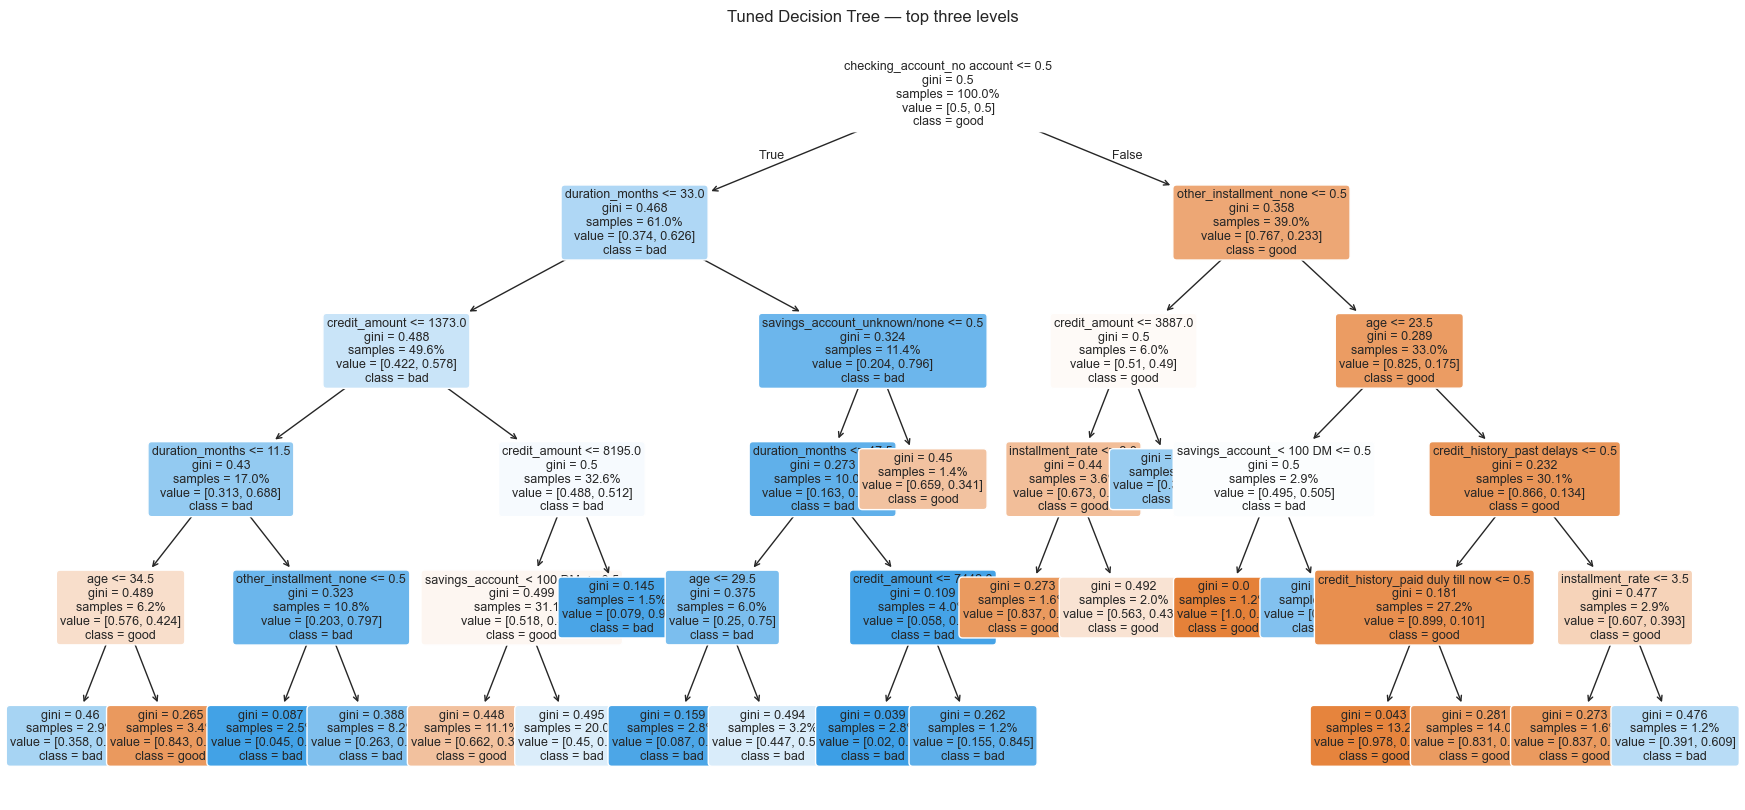

In [160]:
from sklearn.tree import plot_tree

dt_best = grid_dt.best_estimator_
tree_features = [f.replace('cat__', '').replace('remainder__', '')
                 for f in dt_best.named_steps['preprocessor'].get_feature_names_out()]

plt.figure(figsize=(22, 10))
plot_tree(dt_best.named_steps['classifier'],
          feature_names=tree_features,
          class_names=['good', 'bad'],
          filled=True, rounded=True,
          max_depth=10, fontsize=9, proportion=True)
plt.title('Tuned Decision Tree — top three levels')
plt.show()

### Logistic regression odds ratios

Logistic Regression earns its place in the interpretation for two reasons: it stayed within ~0.02 AUC of the ensembles, and its coefficients translate into a language a credit analyst already speaks: **odds ratios**. Exponentiating a coefficient gives the multiplicative change in the *odds* of being a bad risk:

- For a dummy feature, exp(coef) compares that category against the feature's **reference category** — the one dropped during encoding (listed below the table).
- For the standardised numeric features, exp(coef) is the odds multiplier per one standard deviation.

One caveat belongs with this table: these come from a regularised, predictive model. Sklearn provides no standard errors or p-values, and under L2 shrinkage they would not be valid anyway. For formal inference an unpenalised econometric model would be the tool; here the coefficients serve as a directional cross-check.

In [161]:
logreg = grid_logreg.best_estimator_
logreg_pre = logreg.named_steps['preprocessor']

lr_features = [f.replace('cont__', '').replace('cat__', '').replace('ord__', '')
               for f in logreg_pre.get_feature_names_out()]
coefs = logreg.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'feature': lr_features, 'coef': coefs})
           .assign(odds_ratio=lambda d: np.exp(d['coef']),
                   abs_coef=lambda d: d['coef'].abs())
           .sort_values('abs_coef', ascending=False))

coef_df[['feature', 'coef', 'odds_ratio']].head(15).round(3)

,feature,coef,odds_ratio
31,checking_account_no account,-0.905,0.405
40,credit_history_critical account,-0.630,0.532
4,purpose_car (used),-0.538,0.584
3,purpose_car (new),0.477,1.612
0,duration_months,0.444,1.559
20,other_installment_none,-0.435,0.648
33,savings_account_< 100 DM,0.433,1.542
35,savings_account_unknown/none,-0.416,0.660
29,checking_account_< 0 DM,0.413,1.512
41,credit_history_no credits/all paid,0.376,1.456


In [162]:
# Each dummy coefficient is measured against its variable's dropped reference category
ohe = logreg_pre.named_transformers_['cat']
pd.DataFrame({'variable': nominal,
              'reference_category': [c[0] for c in ohe.categories_]})

,variable,reference_category
0,purpose,business
1,personal_status_sex,female div/married
2,other_debtors,co-applicant
3,property,car/other
4,other_installment,bank
5,housing,for free
6,job,management/self-employed
7,telephone,none
8,foreign_worker,no
9,checking_account,0-200 DM


The directions repeat the SHAP story, now in numbers. A few examples:

- `checking_account_no account`: OR ≈ 0.41 — roughly 59% lower odds of being a bad risk than the reference category ("0–200 DM" balance).
- `credit_history_critical account`: OR ≈ 0.55 — about 45% lower odds than the reference ("all paid this bank" — itself one of the riskier histories in the EDA).
- `checking_account_< 0 DM`: OR ≈ 1.54 — about 54% higher odds.
- `duration_months`: OR ≈ 1.56.
- `purpose_car (used)` vs `purpose_car (new)`: a striking pair — relative to the same baseline purpose, used-car loans lower the odds by ~40% while new-car loans raise them by ~66%.

Three independent views: EDA statistics, SHAP on the Random Forest, and logistic regression coefficients tell one consistent story about what drives credit risk in this data. That agreement is what hopefully makes the model's predictions defensible in front of a business audience.

## 9. Conclusions

**What was built.** An end-to-end credit-risk pipeline on the German Credit dataset: SQL-based exploration, EDA, two preprocessing pipelines, a 6-model × 2-strategy comparison (class weighting vs SMOTE) with cross-validated tuning, cost-based model selection with threshold optimisation, a single test-set evaluation, and a multi-angle interpretation.

**The headline result.** A tuned, class-weighted Random Forest operating at a cost-optimal threshold of 0.29:

- catches **83% of bad risks** on unseen data (50 of 60),
- at a total misclassification cost **~30% lower** than the same model at the default threshold (116 vs 165 cost units),
- with a test ROC AUC of 0.789, closely tracking the cross-validated estimate of 0.803 — the model generalises.

**What drives risk.** Checking-account status, loan duration, savings and credit history dominate, confirmed independently by the EDA, SHAP and logistic regression. Two counterintuitive patterns survived every check: clients with *no checking account* and those with a *"critical" credit history* are safer than their labels suggest, most plausibly because both groups are known quantities to the lender.

**Recommendations a bank could act on.**

1. Operate the model at the cost-tuned threshold, not at 0.5 — the 5:1 cost asymmetry makes aggressive flagging profitable even at the price of more manual reviews of good clients.
2. Treat a flag as a triage signal: with precision ~0.43 on the bad class, a flag means "review", not "reject".
3. Watch the strong segments from the EDA: negative checking balance, short employment history, long durations on large amounts as early-warning combinations.

**Limitations.**

- The cost matrix is the dataset's official one; a real lender would calibrate it to its own margins, and the optimal threshold moves with it.
- 1,000 observations from 1970s Germany: the *method* transfers, the specific coefficients do not.